In [1]:
import yfinance as yf
import pandas as pd

# JP Morgan Chase & Co. Common Stock (JPM)

## Collecting data

In [2]:
# Ticker
ticker = "JPM"

# Create a Ticker object
jpm = yf.Ticker(ticker)

In [3]:
'''Date:  from 2020-06-01 to 2020-08-31'''
'''Interval: daily data'''
data_jpm = jpm.history(start="2020-06-01", end="2020-08-31", interval="1d")

## Descriptive statistics

In [4]:
print(data_jpm.head())

                                Open       High        Low      Close  \
Date                                                                    
2020-06-01 00:00:00-04:00  83.435773  84.938046  83.119953  84.161301   
2020-06-02 00:00:00-04:00  85.595294  85.714793  83.589423  84.442986   
2020-06-03 00:00:00-04:00  86.704912  89.555809  86.261056  89.000992   
2020-06-04 00:00:00-04:00  88.616911  90.998353  87.737742  90.853249   
2020-06-05 00:00:00-04:00  98.099991  98.816981  93.490750  94.941811   

                             Volume  Dividends  Stock Splits  
Date                                                          
2020-06-01 00:00:00-04:00  15176800        0.0           0.0  
2020-06-02 00:00:00-04:00  21195000        0.0           0.0  
2020-06-03 00:00:00-04:00  25941100        0.0           0.0  
2020-06-04 00:00:00-04:00  26784700        0.0           0.0  
2020-06-05 00:00:00-04:00  42231000        0.0           0.0  


### Extract only the opening and closing price columns

In [5]:
# Extract only the opening and closing price columns
open_prices = data_jpm["Open"]
close_prices = data_jpm["Close"]

jpm_open_close = pd.DataFrame({"Date": open_prices.index, "Open": open_prices.values, "Close": close_prices.values})
jpm_open_close.reset_index(drop=True, inplace=True)
print(jpm_open_close.head())

                       Date       Open      Close
0 2020-06-01 00:00:00-04:00  83.435773  84.161301
1 2020-06-02 00:00:00-04:00  85.595294  84.442986
2 2020-06-03 00:00:00-04:00  86.704912  89.000992
3 2020-06-04 00:00:00-04:00  88.616911  90.853249
4 2020-06-05 00:00:00-04:00  98.099991  94.941811


### Extract only the closing price columns

In [6]:
# Extract only the closing price column
close_prices = data_jpm["Close"]

jpm_close = pd.DataFrame({"Date": close_prices.index, "Close": close_prices.values})
jpm_close.reset_index(drop=True, inplace=True)

print(jpm_close.head())

                       Date      Close
0 2020-06-01 00:00:00-04:00  84.161301
1 2020-06-02 00:00:00-04:00  84.442986
2 2020-06-03 00:00:00-04:00  89.000992
3 2020-06-04 00:00:00-04:00  90.853249
4 2020-06-05 00:00:00-04:00  94.941811


In [7]:
data_jpm.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,64.000000,64.000000,64.000000,64.000000,6.400000e+01,64.000000,64.0
mean,85.211084,86.240422,83.947569,85.011079,1.990806e+07,0.014063,0.0
std,3.848341,3.765429,3.480349,3.600256,8.104023e+06,0.112500,0.0
min,79.236239,80.447922,78.241507,78.672447,1.048210e+07,0.000000,0.0
25%,83.117923,84.132464,82.402961,83.438265,1.373568e+07,0.000000,0.0
50%,84.817662,85.903267,83.570061,84.623734,1.695900e+07,0.000000,0.0
75%,86.388361,87.616893,85.099941,86.285631,2.486305e+07,0.000000,0.0
max,98.099991,98.816981,95.547855,96.836731,4.273170e+07,0.900000,0.0


In [8]:
data_jpm.shape

(64, 7)

In [9]:
data_jpm.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 64 entries, 2020-06-01 00:00:00-04:00 to 2020-08-28 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          64 non-null     float64
 1   High          64 non-null     float64
 2   Low           64 non-null     float64
 3   Close         64 non-null     float64
 4   Volume        64 non-null     int64  
 5   Dividends     64 non-null     float64
 6   Stock Splits  64 non-null     float64
dtypes: float64(6), int64(1)
memory usage: 4.0 KB


In [10]:
data_jpm.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

## KPIs

### Completeness

In [11]:
missing_values_count = data_jpm.isnull().sum()

print("Missing values per column:")
print(missing_values_count)

Missing values per column:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


In [12]:
'''1.2 Pecetange of the Missing Values'''

total_rows = len(data_jpm)

missing_info = pd.DataFrame({
    'missing_count': data_jpm.isnull().sum(),
    'missing_percentage': (data_jpm.isnull().sum() / total_rows) * 100
})

print(missing_info)

              missing_count  missing_percentage
Open                      0                 0.0
High                      0                 0.0
Low                       0                 0.0
Close                     0                 0.0
Volume                    0                 0.0
Dividends                 0                 0.0
Stock Splits              0                 0.0


### Latency

In [13]:
'''2.1 minimum and Maxmimum Close Price'''
min_close = data_jpm['Close'].min()
max_close = data_jpm['Close'].max()
print(f"Minimum Close Price: {min_close}")
print(f"Maximum Close Price: {max_close}")
print(f"Difference between Max and Min Close Price: {max_close - min_close}")

Minimum Close Price: 78.67244720458984
Maximum Close Price: 96.83673095703125
Difference between Max and Min Close Price: 18.164283752441406


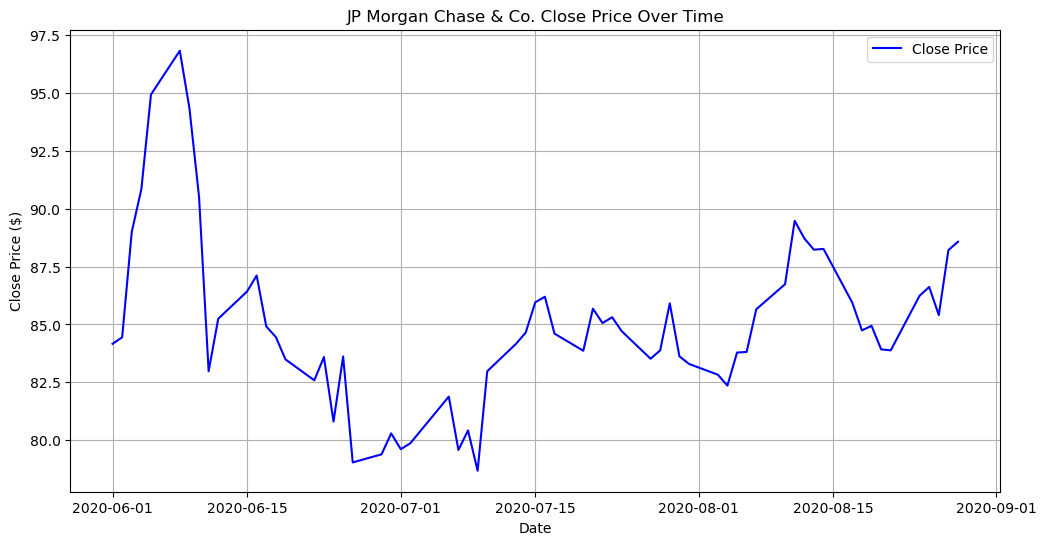

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
# Convert 'Date' column to datetime
jpm_close['Date'] = pd.to_datetime(jpm_close['Date'])


# Set 'Date' as the index 
jpm_close.set_index('Date', inplace=True)


# Plot the time series
plt.figure(figsize=(12,6))
plt.plot(jpm_close.index, jpm_close['Close'], color='blue', label='Close Price')
plt.title('JP Morgan Chase & Co. Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True)
plt.legend()
plt.show()

### Consistency

In [15]:
print(data_jpm.dtypes)

Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object


In [16]:
print(data_jpm.apply(lambda x: x.map(type).nunique()))

Open            1
High            1
Low             1
Close           1
Volume          1
Dividends       1
Stock Splits    1
dtype: int64


### Error rate

In [17]:
# Missing rate
missing_rate = data_jpm.isnull().mean() * 100
print(missing_rate)

Open            0.0
High            0.0
Low             0.0
Close           0.0
Volume          0.0
Dividends       0.0
Stock Splits    0.0
dtype: float64


In [18]:
# Duplicate rate
duplicate_rate = data_jpm.duplicated().mean() * 100
print(duplicate_rate)

0.0


In [19]:
# Outliers
Q1 = data_jpm['Close'].quantile(0.25)
Q3 = data_jpm['Close'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((data_jpm['Close'] < Q1 - 1.5 * IQR) | (data_jpm['Close'] > Q3 + 1.5 * IQR)).mean() * 100
print(outliers)

9.375


## ACCURACY

In [20]:
valid_close = data_jpm['Close'] > 0
valid_volume = data_jpm['Volume'] > 0
valid_dividends = data_jpm['Dividends'] >= 0

accurate_records = data_jpm[valid_close & valid_volume & valid_dividends]
data_accuracy_rate = (len(accurate_records) / len(data_jpm)) * 100
print(f"✅ Data Accuracy Rate: {data_accuracy_rate:.2f}%")

✅ Data Accuracy Rate: 100.00%


In [21]:
invalid_records = data_jpm[~(valid_close & valid_volume & valid_dividends)]
invalid_value_rate = (len(invalid_records) / len(data_jpm)) * 100
print(f"❌ Invalid Value Rate: {invalid_value_rate:.2f}%")

❌ Invalid Value Rate: 0.00%


In [22]:
duplicate_rows = data_jpm.duplicated()
duplicate_accuracy_rate = ((~duplicate_rows).sum() / len(data_jpm)) * 100
print(f"📄 Duplicate Accuracy Rate: {duplicate_accuracy_rate:.2f}%")

📄 Duplicate Accuracy Rate: 100.00%


In [23]:
unit_price_accuracy = (data_jpm['Close'] > 0).sum() / len(data_jpm) * 100
print(f"💰 Close Price Field Accuracy Rate: {unit_price_accuracy:.2f}%")

💰 Close Price Field Accuracy Rate: 100.00%
